# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

## 1.2 Функции

In [2]:
def visualize_predictions_comparison(results_df):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame с колонками ['begin', 'target_price_change', 'predict']
    """
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    results_df = results_df.sort_values('begin')
    
    plt.figure(figsize=(16, 8))
    
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=3, color='#2E8B57', label='Реальное изменение', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=3, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=4, alpha=0.8)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    plt.title('Сравнение реальных и предсказанных изменений цены', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Изменение цены (%)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [3]:
def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")
    
    return {
        'mae': mae,
        'rmse': rmse, 
        'r2': r2,
        'direction_accuracy': direction_accuracy
    }

In [4]:
def train_predict_rf(X_train, X_test, y_train):
    """Быстрый Random Forest с фиксированными гиперпараметрами"""
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=13,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred


def train_predict_dt(X_train, X_test, y_train):
    """Быстрый Decision Tree с фиксированными гиперпараметрами"""
    model = DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        criterion='squared_error',
        random_state=13
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred


def train_predict_linear_reg(X_train, X_test, y_train):
    """Linear Regression с нормализацией"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression(fit_intercept=True)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    return y_pred


def train_predict_catboost(X_train, X_test, y_train):
    """CatBoost с фиксированными гиперпараметрами"""
    model = CatBoostRegressor(
        depth=8,
        iterations=100,
        l2_leaf_reg=3,
        learning_rate=0.01,
        random_state=13,
        verbose=False
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    return y_pred

In [5]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values('begin').reset_index(drop=True)
    
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

# 2 Подготовка данных

## 2.0 Список тикеров

In [6]:
tickers = [
    'SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN'
]

## 2.1 Чтение

In [7]:
data_SBER = pd.read_csv("../../../data/stock_features_data/stocks_features_SBER.csv")
data_TCSG = pd.read_csv("../../../data/stock_features_data/stocks_features_TCSG.csv")
data_GAZP = pd.read_csv("../../../data/stock_features_data/stocks_features_GAZP.csv")
data_LKOH = pd.read_csv("../../../data/stock_features_data/stocks_features_LKOH.csv")
data_ROSN = pd.read_csv("../../../data/stock_features_data/stocks_features_ROSN.csv")

In [8]:
part_SBER = data_SBER[['begin', 'target_class']]
data_SBER.drop('target_class', axis=1, inplace=True)

part_TCSG = data_TCSG[['begin', 'target_class']]
data_TCSG.drop('target_class', axis=1, inplace=True)

part_GAZP = data_GAZP[['begin', 'target_class']]
data_GAZP.drop('target_class', axis=1, inplace=True)

part_LKOH = data_LKOH[['begin', 'target_class']]
data_LKOH.drop('target_class', axis=1, inplace=True)

part_ROSN = data_ROSN[['begin', 'target_class']]
data_ROSN.drop('target_class', axis=1, inplace=True)

## 2.2 Присоединение данных тональности

In [9]:
tonality = pd.read_csv("../../../data/news/ready_news_dataset.csv").drop(columns=['Unnamed: 0', 'text', 'heading', 'sentiment_score'])
tonality.head()

,date,topic,tickers,sector,text_sentiment,reserve_index
0,2022-05-01 00:46:00,finance,[],MOEXFN,positive,"['SBER', 'VTBR']"
1,2022-05-01 01:34:00,economics,[],NaN,neutral,NaN
2,2022-05-01 02:46:00,business,[],MOEXTL,neutral,NaN
3,2022-05-01 05:48:00,business,[],MOEXOG,negative,"['GAZP', 'LKOH', 'ROSN', 'TATN']"
4,2022-05-01 06:37:00,finance,[],MOEXFN,negative,"['SBER', 'VTBR']"


In [10]:
def merge_tonality_with_prices(ticker, price_data, tonality_data, horizons_hours, sector_to_ticker=None):
    """
    Присоединяет числовые признаки тональности к данным цены.

    Логика матчинга новости к тикеру:
    1) tickers
    2) reserve_index
    3) sector -> тикеры

    Кодировка тональности: positive=1, neutral=0, negative=-1

    Args:
        ticker: целевой тикер
        price_data: датафрейм цены с колонкой begin
        tonality_data: датафрейм новостей
        horizons_hours: список горизонтов в часах, например [2] или [2, 24, 72, 168]
    """
    if sector_to_ticker is None:
        sector_to_ticker = {
            'MOEXFN': ['SBER', 'VTBR', 'TCSG'],
            'MOEXOG': ['GAZP', 'LKOH', 'ROSN', 'TATN'],
            'MOEXIT': ['YDEX'],
            'MOEXMM': ['GMKN']
        }

    result = price_data.copy()
    tonality_copy = tonality_data.copy()

    result['begin'] = pd.to_datetime(result['begin'])
    tonality_copy['date'] = pd.to_datetime(tonality_copy['date'])

    def parse_ticker_list(x):
        if pd.isna(x) or x == '' or x == '[]':
            return []
        if isinstance(x, str):
            x = x.strip('[]')
            if not x:
                return []
            return [t.upper().strip().strip("'\"") for t in x.split(',') if t.strip()]
        if isinstance(x, (list, tuple, set)):
            return [str(t).upper().strip() for t in x if str(t).strip()]
        return []

    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}

    tonality_copy['tickers_list'] = tonality_copy['tickers'].apply(parse_ticker_list)
    tonality_copy['reserve_list'] = tonality_copy.get('reserve_index', pd.NA).apply(parse_ticker_list)
    tonality_copy['sentiment_value'] = tonality_copy['text_sentiment'].map(sentiment_map)

    def is_news_for_ticker(row, target_ticker):
        target = target_ticker.upper()
        if target in row['tickers_list']:
            return True
        if target in row['reserve_list']:
            return True
        sector = str(row.get('sector', '')).upper()
        return target in [t.upper() for t in sector_to_ticker.get(sector, [])]

    news_for_ticker = tonality_copy[
        tonality_copy.apply(lambda row: is_news_for_ticker(row, ticker), axis=1)
    ].copy()

    if len(news_for_ticker) == 0:
        for h in horizons_hours:
            col = 'text_sentiment' if h == 2 else f'text_sentiment_{h}h'
            result[col] = np.nan
        return result

    for h in horizons_hours:
        col = 'text_sentiment' if h == 2 else f'text_sentiment_{h}h'
        result[col] = np.nan

    unique_times = sorted(result['begin'].unique())

    for current_time in unique_times:
        for h in horizons_hours:
            window_start = current_time - pd.Timedelta(hours=h)
            mask_news = (news_for_ticker['date'] > window_start) & (news_for_ticker['date'] <= current_time)
            window_news = news_for_ticker.loc[mask_news, 'sentiment_value'].dropna()
            if len(window_news) > 0:
                col = 'text_sentiment' if h == 2 else f'text_sentiment_{h}h'
                result.loc[result['begin'] == current_time, col] = window_news.mean()

    return result

In [11]:
# Версия 1: только 2 часа (один признак text_sentiment)
data_SBER_with_sentiment = merge_tonality_with_prices('SBER', data_SBER, tonality, horizons_hours=[2])
data_TCSG_with_sentiment = merge_tonality_with_prices('TCSG', data_TCSG, tonality, horizons_hours=[2])
data_GAZP_with_sentiment = merge_tonality_with_prices('GAZP', data_GAZP, tonality, horizons_hours=[2])
data_LKOH_with_sentiment = merge_tonality_with_prices('LKOH', data_LKOH, tonality, horizons_hours=[2])
data_ROSN_with_sentiment = merge_tonality_with_prices('ROSN', data_ROSN, tonality, horizons_hours=[2])

# Версия 2: мульти-окно (2ч, 24ч, 72ч, 7д)
data_SBER_with_sentiment_multi = merge_tonality_with_prices('SBER', data_SBER, tonality, horizons_hours=[2, 24, 72, 168])
data_TCSG_with_sentiment_multi = merge_tonality_with_prices('TCSG', data_TCSG, tonality, horizons_hours=[2, 24, 72, 168])
data_GAZP_with_sentiment_multi = merge_tonality_with_prices('GAZP', data_GAZP, tonality, horizons_hours=[2, 24, 72, 168])
data_LKOH_with_sentiment_multi = merge_tonality_with_prices('LKOH', data_LKOH, tonality, horizons_hours=[2, 24, 72, 168])
data_ROSN_with_sentiment_multi = merge_tonality_with_prices('ROSN', data_ROSN, tonality, horizons_hours=[2, 24, 72, 168])

In [12]:
print(data_SBER_with_sentiment['text_sentiment'].isna().sum() / len(data_SBER_with_sentiment))
print(data_TCSG_with_sentiment['text_sentiment'].isna().sum() / len(data_TCSG_with_sentiment))
print(data_GAZP_with_sentiment['text_sentiment'].isna().sum() / len(data_GAZP_with_sentiment))
print(data_LKOH_with_sentiment['text_sentiment'].isna().sum() / len(data_LKOH_with_sentiment))
print(data_ROSN_with_sentiment['text_sentiment'].isna().sum() / len(data_ROSN_with_sentiment))

0.04834849210148397
0.02698913424465475
0.0308760172331259
0.031115366203925323
0.03135471517472475


## 2.3 Разделение на train/test

In [13]:
# Версия с 2-часовой тональностью
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER_with_sentiment,
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=data_TCSG_with_sentiment,
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP_with_sentiment,
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=data_LKOH_with_sentiment,
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=data_ROSN_with_sentiment,
    target_column='target_price_change',
    test_size=0.2
)

# Версия с мульти-окном тональности
X_train_SBER_multi, X_test_SBER_multi, y_train_SBER_multi, y_test_SBER_multi = train_test_split_by_date(
    df=data_SBER_with_sentiment_multi,
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG_multi, X_test_TCSG_multi, y_train_TCSG_multi, y_test_TCSG_multi = train_test_split_by_date(
    df=data_TCSG_with_sentiment_multi,
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP_multi, X_test_GAZP_multi, y_train_GAZP_multi, y_test_GAZP_multi = train_test_split_by_date(
    df=data_GAZP_with_sentiment_multi,
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH_multi, X_test_LKOH_multi, y_train_LKOH_multi, y_test_LKOH_multi = train_test_split_by_date(
    df=data_LKOH_with_sentiment_multi,
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN_multi, X_test_ROSN_multi, y_train_ROSN_multi, y_test_ROSN_multi = train_test_split_by_date(
    df=data_ROSN_with_sentiment_multi,
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 85
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 88
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 88
Train: 2022-0

In [14]:
# 2.4 Иммутация пропусков после присоединения тональности
# Версия с 2-часовой тональностью
X_train_SBER = X_train_SBER.fillna(0)
X_test_SBER = X_test_SBER.fillna(0)
X_train_TCSG = X_train_TCSG.fillna(0)
X_test_TCSG = X_test_TCSG.fillna(0)
X_train_GAZP = X_train_GAZP.fillna(0)
X_test_GAZP = X_test_GAZP.fillna(0)
X_train_LKOH = X_train_LKOH.fillna(0)
X_test_LKOH = X_test_LKOH.fillna(0)
X_train_ROSN = X_train_ROSN.fillna(0)
X_test_ROSN = X_test_ROSN.fillna(0)

# Версия с мульти-окном тональности
X_train_SBER_multi = X_train_SBER_multi.fillna(0)
X_test_SBER_multi = X_test_SBER_multi.fillna(0)
X_train_TCSG_multi = X_train_TCSG_multi.fillna(0)
X_test_TCSG_multi = X_test_TCSG_multi.fillna(0)
X_train_GAZP_multi = X_train_GAZP_multi.fillna(0)
X_test_GAZP_multi = X_test_GAZP_multi.fillna(0)
X_train_LKOH_multi = X_train_LKOH_multi.fillna(0)
X_test_LKOH_multi = X_test_LKOH_multi.fillna(0)
X_train_ROSN_multi = X_train_ROSN_multi.fillna(0)
X_test_ROSN_multi = X_test_ROSN_multi.fillna(0)

print('Пропуски в версиях with_2h и with_multi заполнены нулями')

Пропуски в версиях with_2h и with_multi заполнены нулями


In [15]:
# Данные без признака тональности (базовый вариант)
X_train_SBER_old, X_test_SBER_old, y_train_SBER_old, y_test_SBER_old = train_test_split_by_date(
    df=data_SBER,
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG_old, X_test_TCSG_old, y_train_TCSG_old, y_test_TCSG_old = train_test_split_by_date(
    df=data_TCSG,
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP_old, X_test_GAZP_old, y_train_GAZP_old, y_test_GAZP_old = train_test_split_by_date(
    df=data_GAZP,
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH_old, X_test_LKOH_old, y_train_LKOH_old, y_test_LKOH_old = train_test_split_by_date(
    df=data_LKOH,
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN_old, X_test_ROSN_old, y_train_ROSN_old, y_test_ROSN_old = train_test_split_by_date(
    df=data_ROSN,
    target_column='target_price_change',
    test_size=0.2
)

X_train_SBER_old = X_train_SBER_old.fillna(0)
X_test_SBER_old = X_test_SBER_old.fillna(0)
X_train_TCSG_old = X_train_TCSG_old.fillna(0)
X_test_TCSG_old = X_test_TCSG_old.fillna(0)
X_train_GAZP_old = X_train_GAZP_old.fillna(0)
X_test_GAZP_old = X_test_GAZP_old.fillna(0)
X_train_LKOH_old = X_train_LKOH_old.fillna(0)
X_test_LKOH_old = X_test_LKOH_old.fillna(0)
X_train_ROSN_old = X_train_ROSN_old.fillna(0)
X_test_ROSN_old = X_test_ROSN_old.fillna(0)

Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 84


# 3 Быстрый Экспериментальный Пайплайн

## 3.1 Быстрые Эксперименты Без GridSearch

### Сравнение По Всем Тикерам

In [16]:
experiments = {
    'SBER': {
        'no_sent': (X_train_SBER_old, X_test_SBER_old, y_train_SBER_old, y_test_SBER_old),
        'sent_2h': (X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER),
        'sent_multi': (X_train_SBER_multi, X_test_SBER_multi, y_train_SBER_multi, y_test_SBER_multi)
    },
    'TCSG': {
        'no_sent': (X_train_TCSG_old, X_test_TCSG_old, y_train_TCSG_old, y_test_TCSG_old),
        'sent_2h': (X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG),
        'sent_multi': (X_train_TCSG_multi, X_test_TCSG_multi, y_train_TCSG_multi, y_test_TCSG_multi)
    },
    'GAZP': {
        'no_sent': (X_train_GAZP_old, X_test_GAZP_old, y_train_GAZP_old, y_test_GAZP_old),
        'sent_2h': (X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP),
        'sent_multi': (X_train_GAZP_multi, X_test_GAZP_multi, y_train_GAZP_multi, y_test_GAZP_multi)
    },
    'LKOH': {
        'no_sent': (X_train_LKOH_old, X_test_LKOH_old, y_train_LKOH_old, y_test_LKOH_old),
        'sent_2h': (X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH),
        'sent_multi': (X_train_LKOH_multi, X_test_LKOH_multi, y_train_LKOH_multi, y_test_LKOH_multi)
    },
    'ROSN': {
        'no_sent': (X_train_ROSN_old, X_test_ROSN_old, y_train_ROSN_old, y_test_ROSN_old),
        'sent_2h': (X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN),
        'sent_multi': (X_train_ROSN_multi, X_test_ROSN_multi, y_train_ROSN_multi, y_test_ROSN_multi)
    }
}

rows = []
predictions_2h = {}
predictions_multi = {}

for ticker_name, cfg in experiments.items():
    # 1) без тональности
    X_tr0, X_te0, y_tr0, y_te0 = cfg['no_sent']
    y_pred0 = train_predict_rf(X_tr0, X_te0, y_tr0)
    m0 = evaluate_regression(y_te0, y_pred0, model_name=f'{ticker_name} RF no sentiment')

    # 2) тональность 2ч
    X_tr2, X_te2, y_tr2, y_te2 = cfg['sent_2h']
    y_pred2 = train_predict_rf(X_tr2, X_te2, y_tr2)
    m2 = evaluate_regression(y_te2, y_pred2, model_name=f'{ticker_name} RF sentiment 2h')

    # 3) тональность multi: 2ч/24ч/72ч/7д
    X_trm, X_tem, y_trm, y_tem = cfg['sent_multi']
    y_predm = train_predict_rf(X_trm, X_tem, y_trm)
    mm = evaluate_regression(y_tem, y_predm, model_name=f'{ticker_name} RF sentiment multi')

    predictions_2h[ticker_name] = y_pred2
    predictions_multi[ticker_name] = y_predm

    rows.append({
        'ticker': ticker_name,
        'mae_no_sent': m0['mae'],
        'mae_sent_2h': m2['mae'],
        'mae_sent_multi': mm['mae'],
        'rmse_no_sent': m0['rmse'],
        'rmse_sent_2h': m2['rmse'],
        'rmse_sent_multi': mm['rmse'],
        'r2_no_sent': m0['r2'],
        'r2_sent_2h': m2['r2'],
        'r2_sent_multi': mm['r2'],
        'direction_no_sent': m0['direction_accuracy'],
        'direction_sent_2h': m2['direction_accuracy'],
        'direction_sent_multi': mm['direction_accuracy']
    })

results_compare = pd.DataFrame(rows)

results_compare['delta_mae_2h_vs_no'] = results_compare['mae_sent_2h'] - results_compare['mae_no_sent']
results_compare['delta_mae_multi_vs_no'] = results_compare['mae_sent_multi'] - results_compare['mae_no_sent']
results_compare['delta_rmse_2h_vs_no'] = results_compare['rmse_sent_2h'] - results_compare['rmse_no_sent']
results_compare['delta_rmse_multi_vs_no'] = results_compare['rmse_sent_multi'] - results_compare['rmse_no_sent']
results_compare['delta_r2_2h_vs_no'] = results_compare['r2_sent_2h'] - results_compare['r2_no_sent']
results_compare['delta_r2_multi_vs_no'] = results_compare['r2_sent_multi'] - results_compare['r2_no_sent']
results_compare['delta_direction_2h_vs_no'] = results_compare['direction_sent_2h'] - results_compare['direction_no_sent']
results_compare['delta_direction_multi_vs_no'] = results_compare['direction_sent_multi'] - results_compare['direction_no_sent']

y_pred_SBER = predictions_2h['SBER']
y_pred_GAZP = predictions_2h['GAZP']

results_compare


📊 МОДЕЛЬ: SBER RF no sentiment
MAE: 2.4427%
RMSE: 2.9859%
R²: -0.1619
Accuracy направления: 0.4928

📊 МОДЕЛЬ: SBER RF sentiment 2h
MAE: 2.4264%
RMSE: 2.9714%
R²: -0.1507
Accuracy направления: 0.4581

📊 МОДЕЛЬ: SBER RF sentiment multi
MAE: 2.4277%
RMSE: 2.9759%
R²: -0.1542
Accuracy направления: 0.4940

📊 МОДЕЛЬ: TCSG RF no sentiment
MAE: 3.8957%
RMSE: 5.0438%
R²: -0.0877
Accuracy направления: 0.5447

📊 МОДЕЛЬ: TCSG RF sentiment 2h
MAE: 3.9276%
RMSE: 5.0643%
R²: -0.0966
Accuracy направления: 0.5114

📊 МОДЕЛЬ: TCSG RF sentiment multi
MAE: 3.9444%
RMSE: 5.1045%
R²: -0.1141
Accuracy направления: 0.5149

📊 МОДЕЛЬ: GAZP RF no sentiment
MAE: 4.4301%
RMSE: 5.7992%
R²: 0.0663
Accuracy направления: 0.6842

📊 МОДЕЛЬ: GAZP RF sentiment 2h
MAE: 4.4338%
RMSE: 5.8063%
R²: 0.0640
Accuracy направления: 0.6902

📊 МОДЕЛЬ: GAZP RF sentiment multi
MAE: 4.4219%
RMSE: 5.8204%
R²: 0.0594
Accuracy направления: 0.6746

📊 МОДЕЛЬ: LKOH RF no sentiment
MAE: 3.7393%
RMSE: 4.4808%
R²: -0.5733
Accuracy направления: 0

,ticker,mae_no_sent,mae_sent_2h,mae_sent_multi,rmse_no_sent,rmse_sent_2h,rmse_sent_multi,r2_no_sent,r2_sent_2h,r2_sent_multi,...,direction_sent_2h,direction_sent_multi,delta_mae_2h_vs_no,delta_mae_multi_vs_no,delta_rmse_2h_vs_no,delta_rmse_multi_vs_no,delta_r2_2h_vs_no,delta_r2_multi_vs_no,delta_direction_2h_vs_no,delta_direction_multi_vs_no
0,SBER,2.442708,2.426434,2.427659,2.985862,2.971430,2.975936,-0.161882,-0.150677,-0.154170,...,0.458134,0.494019,-0.016274,-0.015049,-0.014432,-0.009926,0.011205,0.007712,-0.034689,0.001196
1,TCSG,3.895664,3.927635,3.944443,5.043776,5.064276,5.104539,-0.087724,-0.096583,-0.114089,...,0.511384,0.514886,0.031970,0.048778,0.020499,0.060762,-0.008859,-0.026365,-0.033275,-0.029772
2,GAZP,4.430119,4.433833,4.421872,5.799185,5.806306,5.820390,0.066270,0.063975,0.059429,...,0.690191,0.674641,0.003715,-0.008246,0.007121,0.021205,-0.002295,-0.006841,0.005981,-0.009569
3,LKOH,3.739339,3.757251,3.677147,4.480764,4.495985,4.399248,-0.573254,-0.583961,-0.516533,...,0.468900,0.465311,0.017912,-0.062193,0.015221,-0.081516,-0.010707,0.056722,0.009569,0.005981
4,ROSN,4.683831,4.603932,4.510874,5.895858,5.806521,5.688688,-0.726250,-0.674332,-0.607066,...,0.470096,0.476077,-0.079899,-0.172957,-0.089338,-0.207171,0.051918,0.119184,-0.004785,0.001196


In [17]:
results_compare[results_compare['ticker'] == 'GAZP'][['r2_no_sent', 'r2_sent_2h', 'r2_sent_multi', 'direction_no_sent', 'direction_sent_2h', 'direction_sent_multi']]

,r2_no_sent,r2_sent_2h,r2_sent_multi,direction_no_sent,direction_sent_2h,direction_sent_multi
2,0.06627,0.063975,0.059429,0.684211,0.690191,0.674641


In [18]:
results_compare[['ticker', 'r2_no_sent', 'r2_sent_2h', 'r2_sent_multi', 'direction_no_sent', 'direction_sent_2h', 'direction_sent_multi']]

,ticker,r2_no_sent,r2_sent_2h,r2_sent_multi,direction_no_sent,direction_sent_2h,direction_sent_multi
0,SBER,-0.161882,-0.150677,-0.154170,0.492823,0.458134,0.494019
1,TCSG,-0.087724,-0.096583,-0.114089,0.544658,0.511384,0.514886
2,GAZP,0.066270,0.063975,0.059429,0.684211,0.690191,0.674641
3,LKOH,-0.573254,-0.583961,-0.516533,0.459330,0.468900,0.465311
4,ROSN,-0.726250,-0.674332,-0.607066,0.474880,0.470096,0.476077


## Вывод
По качеству регрессии лучшим в целом выглядит мульти-окно: оно дает самый заметный выигрыш на LKOH и ROSN, а также почти не уступает базе на SBER. Версия с 2-часовой тональностью дает небольшой плюс только на SBER и ROSN, но на TCSG и LKOH не помогает. Для направления движения картина слабее: без тональности лучше на SBER и TCSG, с 2-часовой тональностью чуть лучше на GAZP, а мульти-окно почти не меняет результат и чаще всего остается близко к базе. Итог: тональность полезна не везде, но как набор нескольких окон она выглядит наиболее устойчивой для оценки величины изменения, тогда как для знака изменения явного преимущества нет.

# 4 Визуализация резульататов

## 4.1 Сбер

In [31]:
df_SBER_pred = pd.DataFrame(y_test_SBER)
df_SBER_pred = df_SBER_pred.merge(data_SBER[['begin', 'close']], left_index=True, right_index=True)
df_SBER_pred['predict'] = y_pred_SBER
df_SBER_pred.head()

,target_price_change,begin,close,predict
3342,-1.326195,2025-03-17 18:00:00,324.99,-0.394063
3343,-1.666462,2025-03-18 10:00:00,326.44,-0.459403
3344,-2.412803,2025-03-18 12:00:00,327.42,-0.541087
3345,-2.845628,2025-03-18 14:00:00,327.52,-0.625851
3346,-3.348526,2025-03-18 16:00:00,329.10,-0.627291


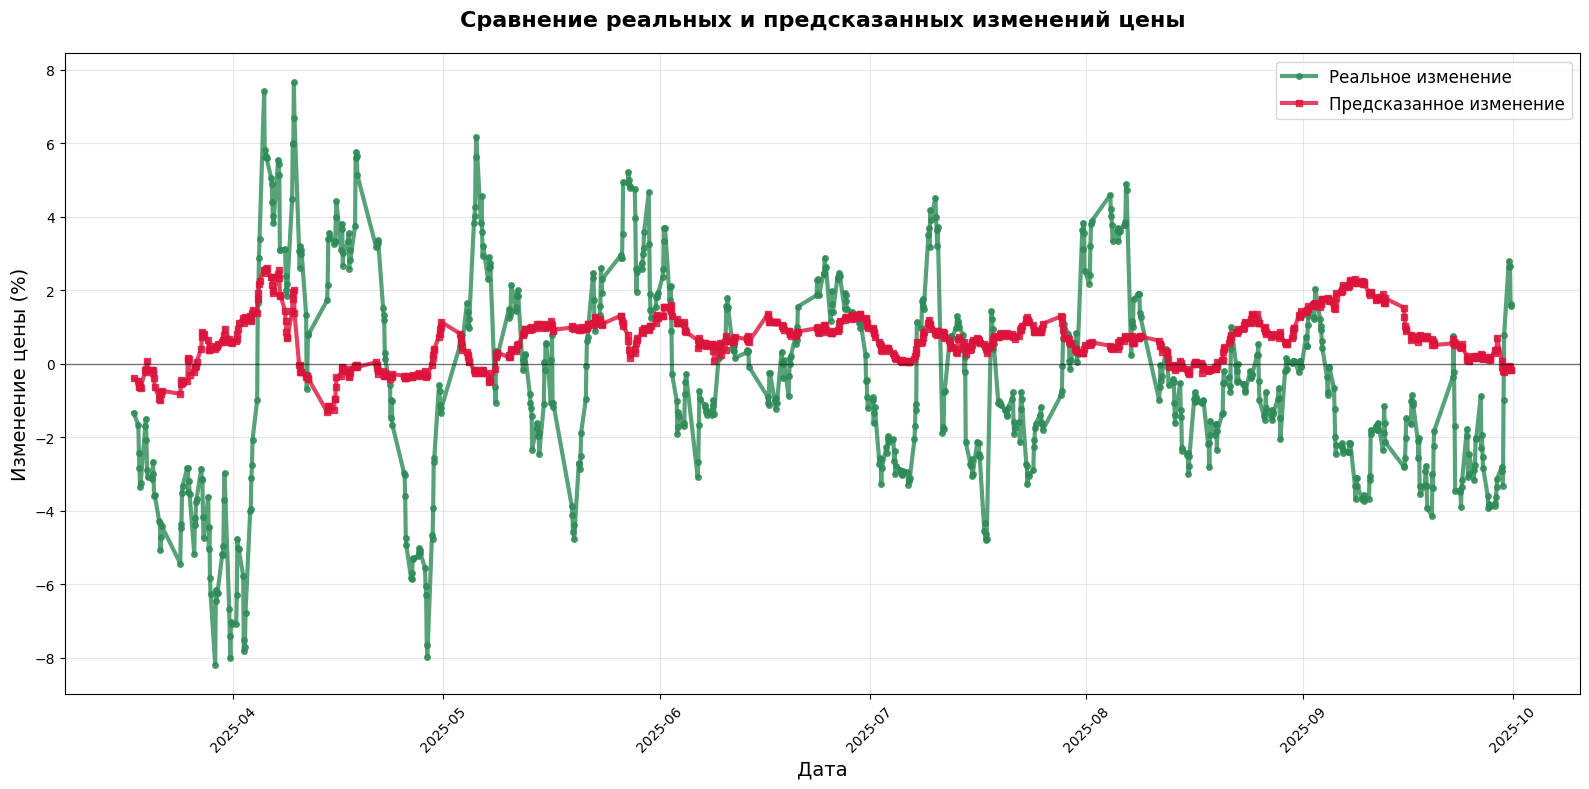

In [32]:
visualize_predictions_comparison(df_SBER_pred)

## 4.2 Газпром

In [19]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(data_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
df_GAZP_pred.head()

,target_price_change,begin,close,predict
3342,-5.166964,2025-03-17 18:00:00,173.99,-1.930930
3343,-4.523397,2025-03-18 10:00:00,173.10,-1.535449
3344,-5.911188,2025-03-18 12:00:00,173.40,-0.881724
3345,-6.261201,2025-03-18 14:00:00,172.97,-0.212798
3346,-5.948191,2025-03-18 16:00:00,173.33,0.033418


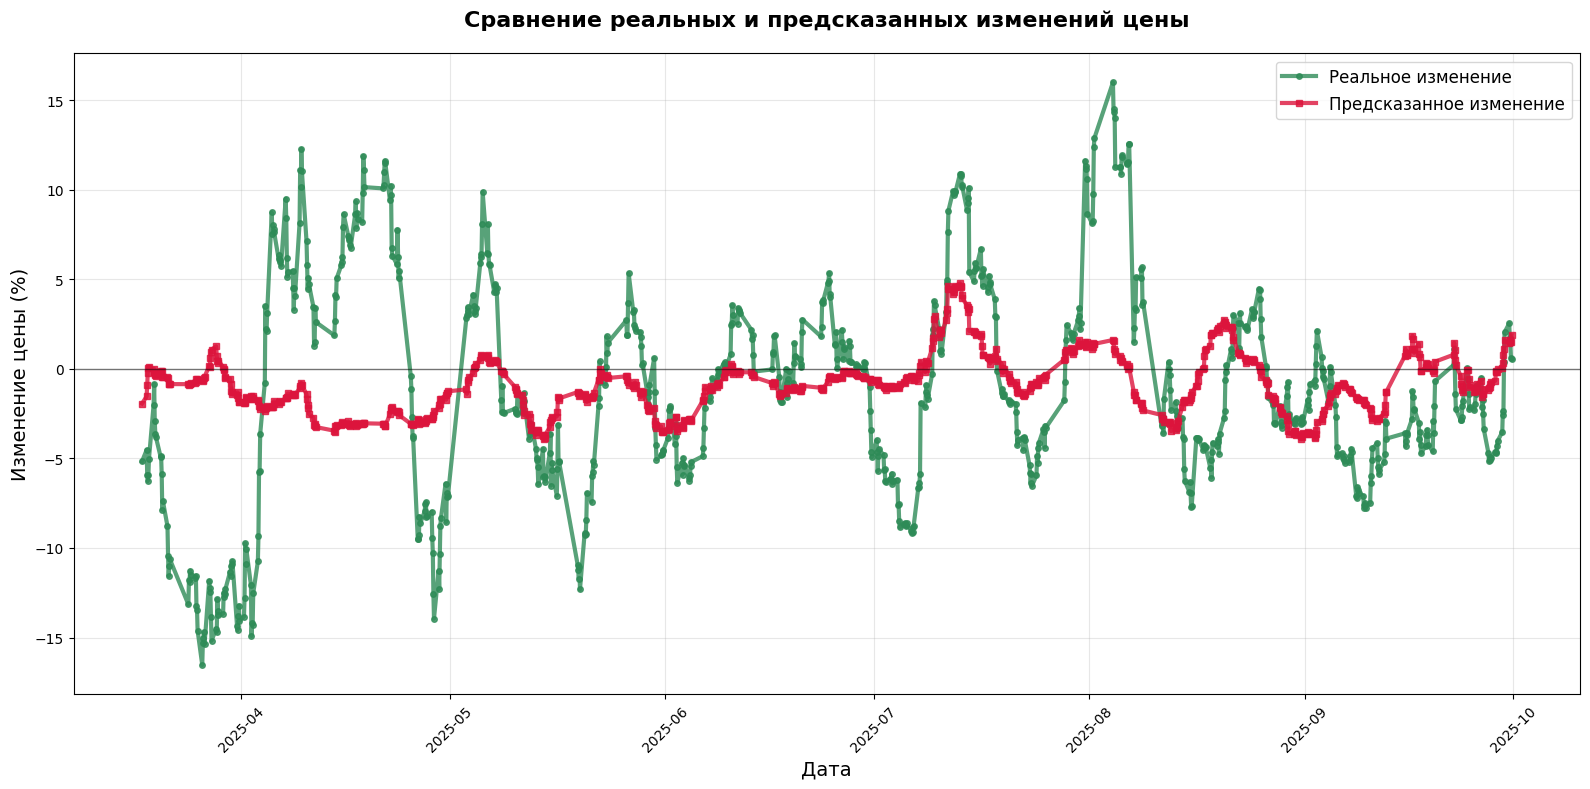

In [20]:
visualize_predictions_comparison(df_GAZP_pred)